<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/golf/02_angle_geometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Golf putting 2 — Geometry: angle error

Replace the generic logistic curve with a one-parameter model derived from the geometry of a ball entering a cup. Fit it to the Berry data, then test the already-fit model on the later Broadie data **without refitting**.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "jinja2>=3.1.5"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260923
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

DATA_BASE = "https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/golf/data"
golf = pd.read_csv(f"{DATA_BASE}/berry_1996_putting.csv")
golf["rate"] = golf["made"] / golf["attempts"]

BALL_RADIUS_FT = (1.68 / 2) / 12
CUP_RADIUS_FT = (4.25 / 2) / 12

golf

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


,distance_ft,attempts,made,rate
0,2,1443,1346,0.932779
1,3,694,577,0.831412
2,4,455,337,0.740659
3,5,353,208,0.589235
4,6,272,149,0.547794
5,7,256,136,0.531250
6,8,240,111,0.462500
7,9,217,69,0.317972
8,10,200,67,0.335000
9,11,237,75,0.316456


In [3]:
DRAW_COLOR = "#12505e"  # darker shade of the band colour C0

def plot_curve_draws(ax, x, curves):
    """Thin lines for individual draws of the success-probability curve."""
    ax.plot(x, curves, color=DRAW_COLOR, lw=0.8, alpha=0.55, zorder=1.5)

def plot_simulated_datasets(ax, x, datasets):
    """Dots for simulated rates, nudged sideways so nearby values stay visible."""
    jitter = np.random.default_rng(RANDOM_SEED).uniform(-0.15, 0.15, datasets.shape)
    ax.set_autoscalex_on(False)  # keep the same distance axis as the other plots
    ax.scatter(
        np.asarray(x)[:, None] + jitter,
        datasets,
        s=14,
        color=DRAW_COLOR,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.4,
        zorder=1.5,
    )

def add_interval_legend(ax, line_label="mean", draws_label="20 draws", draws_as_points=False):
    """Compact one-row legend above the plot, so it never hides draws or data."""
    if draws_as_points:
        draws_handle = Line2D(
            [0], [0], marker="o", linestyle="none", color=DRAW_COLOR,
            markersize=4, label=draws_label,
        )
    else:
        draws_handle = Line2D([0], [0], color=DRAW_COLOR, lw=0.9, label=draws_label)
    ax.legend(
        handles=[
            Line2D([0], [0], color="C1", lw=1.6, label=line_label),
            Patch(facecolor="C0", alpha=0.9, label="50% HDI"),
            Patch(facecolor="C0", alpha=0.28, label="90% HDI"),
            draws_handle,
            Line2D(
                [0], [0], marker="o", linestyle="none", color="black",
                markersize=4.5, label="observed",
            ),
        ],
        loc="lower left",
        bbox_to_anchor=(0, 1.01),
        ncols=5,
        fontsize=8,
        handlelength=1.4,
        handletextpad=0.45,
        columnspacing=0.9,
        borderaxespad=0,
        frameon=False,
    )

def plot_residuals(idata, data, var_name="p_base", title="Residuals"):
    """Plot observed minus posterior-median mechanistic probability."""
    fitted = idata["posterior"][var_name].median(dim=("chain", "draw")).to_numpy()
    x = data["distance_ft"].to_numpy()
    residual = data["rate"].to_numpy() - fitted
    order = np.argsort(x)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.plot(x[order], residual[order], marker="o")
    ax.set(
        xlabel="Distance from hole (feet)",
        ylabel="Observed − fitted probability",
        title=title,
    )
    return ax

## Model from first principles

If a golfer aims straight but the actual direction has Normal angular error with standard deviation $\sigma_{angle}$, a putt from distance $x$ succeeds when the angular error stays within

$$
\theta(x)=\arcsin\!\left(\frac{R-r}{x}\right).
$$

Thus

$$
p(x)=2\Phi\!\left(\frac{\theta(x)}{\sigma_{angle}}\right)-1.
$$

We put the prior directly on $\sigma_{angle}$ in **degrees**.

In [4]:
coords = {"obs_id": golf["distance_ft"].to_numpy()}

with pm.Model(coords=coords) as model:
    distance = pm.Data("distance", golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_base = pm.Deterministic(
        "p_base",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    made = pm.Binomial(
        "made",
        n=attempts,
        p=p_base,
        observed=golf["made"].to_numpy(),
        dims="obs_id",
    )

## Prior predictive check

Before fitting, ask what success rates the prior says are plausible across putting distance. The observed rates are shown only as a reference; they do not condition the prior. The dots are 20 simulated datasets, nudged sideways so nearby values stay visible.

In [5]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["made"],
        random_seed=RANDOM_SEED,
    )

Sampling: [made, sigma_angle_deg]


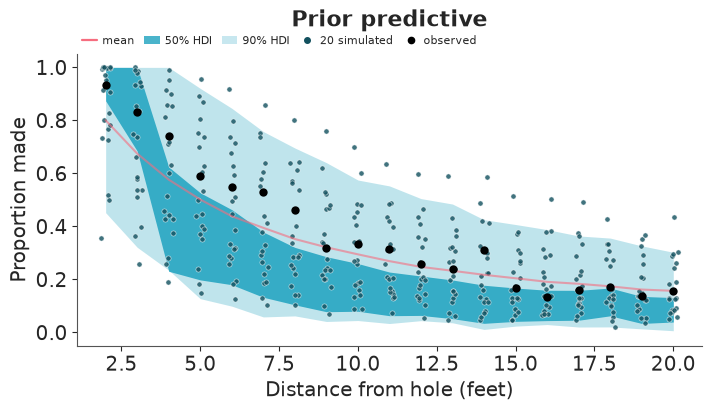

In [6]:
# Plot on the rate scale: made / attempts at each distance.
prior["observed_data"]["rate"] = prior["observed_data"]["made"] / prior["constant_data"]["attempts"]
prior["prior_predictive"]["rate"] = (
    prior["prior_predictive"]["made"] / prior["constant_data"]["attempts"]
)
prior_datasets = azb.extract(
    prior,
    group="prior_predictive",
    var_names="rate",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    prior,
    x="distance",
    y="rate",
    y_obs="rate",
    group="prior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, golf["distance_ft"], prior_datasets)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Prior predictive", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
plt.show()

## Fit and diagnose

Do not interpret the scientific fit until the sampler diagnostics are acceptable.

In [7]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata,
    var_names=['sigma_angle_deg'],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [sigma_angle_deg]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_angle_deg,1.53,0.02,1.49,1.56,1367.19,1936.84,1.0,0.0,0.0


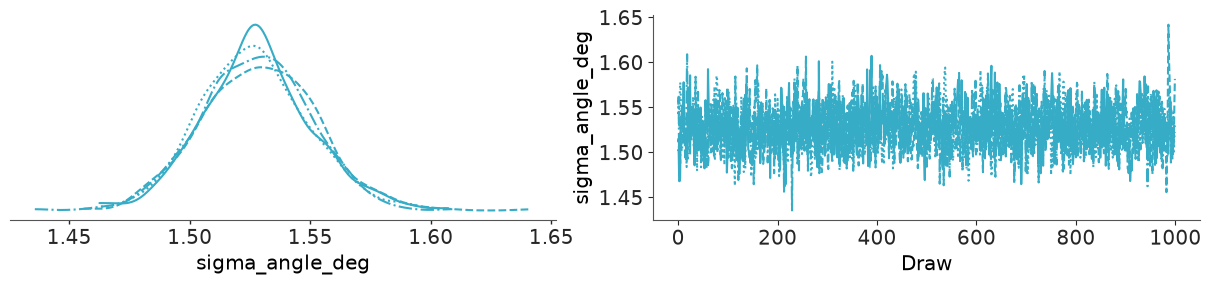

In [8]:
azp.plot_trace_dist(idata, var_names=['sigma_angle_deg']);

## Posterior fit

This plot shows posterior uncertainty in the continuous mechanistic success-probability relationship $p_{base}(x)$. It does not include the additional variation in newly observed successes. The thin lines are 20 posterior draws of that curve.

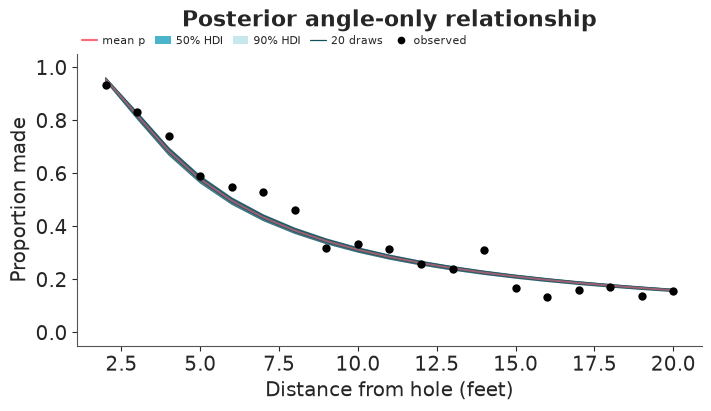

In [9]:
idata["observed_data"]["rate"] = idata["observed_data"]["made"] / idata["constant_data"]["attempts"]
posterior_curves = azb.extract(
    idata,
    group="posterior",
    var_names="p_base",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="distance",
    y="p_base",
    y_obs="rate",
    group="posterior",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_curve_draws(ax, golf["distance_ft"], posterior_curves)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Posterior angle-only relationship", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean p", draws_label="20 draws")
plt.show()

## Posterior predictive check

Now generate new outcomes at the same putting distances from the fitted model. This uses the same graphical grammar as the prior predictive check; the difference is that these predictions are conditioned on the observed data. Each of the 20 simulated datasets comes from one of the 20 curves drawn above.

In [10]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["made"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [made]


Output()

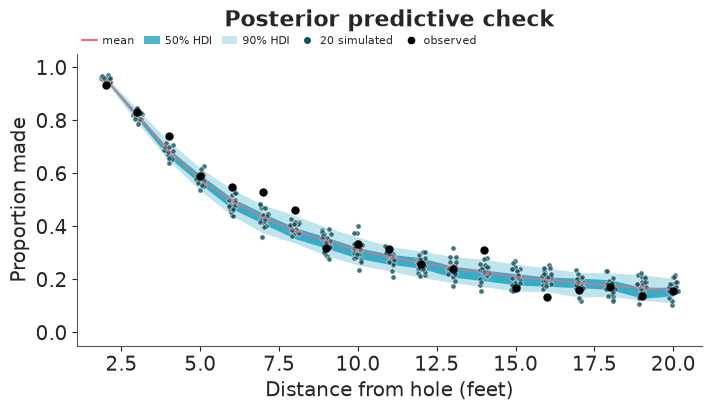

In [11]:
# sample_posterior_predictive replaced observed_data, so add the observed rate again.
idata["observed_data"]["rate"] = idata["observed_data"]["made"] / idata["constant_data"]["attempts"]
idata["posterior_predictive"]["rate"] = (
    idata["posterior_predictive"]["made"] / idata["constant_data"]["attempts"]
)
# Same seed and number of draws as the curves above: dataset i comes from curve i.
posterior_datasets = azb.extract(
    idata,
    group="posterior_predictive",
    var_names="rate",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    idata,
    x="distance",
    y="rate",
    y_obs="rate",
    group="posterior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_simulated_datasets(ax, golf["distance_ft"], posterior_datasets)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Posterior predictive check", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean", draws_label="20 simulated", draws_as_points=True)
plt.show()

## Model criticism

These residuals compare the observed rates with the posterior-median mechanistic relationship $p_{base}(x)$. They are a check for systematic structure in the mechanism, not a posterior predictive interval.

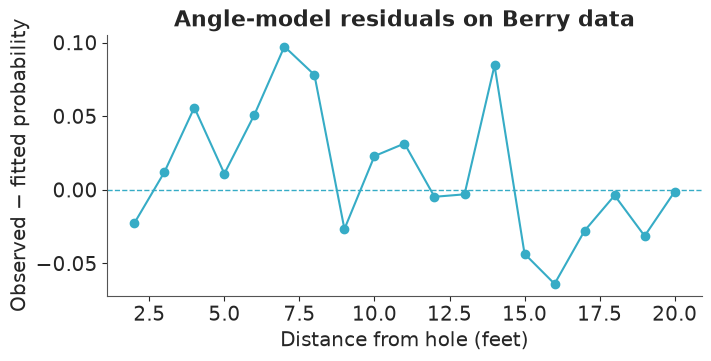

In [12]:
plot_residuals(idata, golf, var_name="p_base", title="Angle-model residuals on Berry data");

## External check on newer data

Now extend the curve fitted to the Berry data to the Broadie distances, as the book does (Figure 25.5). We do **not** refit: `pm.sample_posterior_predictive` only recomputes $p_{base}(x)$ from the Berry posterior draws. The Broadie outcomes are passed as `observed` only so that they are stored alongside the curves for plotting.

In [13]:
new_golf = pd.read_csv(f"{DATA_BASE}/broadie_2018_putting.csv")
new_golf["rate"] = new_golf["made"] / new_golf["attempts"]

# The same model, set up at the Broadie distances.
new_coords = {"obs_id": new_golf["distance_ft"].to_numpy()}
with pm.Model(coords=new_coords) as prediction_model:
    distance = pm.Data("distance", new_golf["distance_ft"].to_numpy(), dims="obs_id")
    attempts = pm.Data("attempts", new_golf["attempts"].to_numpy(), dims="obs_id")
    sigma_angle_deg = pm.LogNormal("sigma_angle_deg", mu=np.log(2), sigma=0.7)
    sigma_angle_rad = sigma_angle_deg * np.pi / 180
    threshold_angle = pm.math.arcsin((CUP_RADIUS_FT - BALL_RADIUS_FT) / distance)
    p_base = pm.Deterministic(
        "p_base",
        2 * pm.math.invprobit(threshold_angle / sigma_angle_rad) - 1,
        dims="obs_id",
    )
    made = pm.Binomial(
        "made",
        n=attempts,
        p=p_base,
        observed=new_golf["made"].to_numpy(),
        dims="obs_id",
    )

    # Recompute p_base from the Berry posterior draws; nothing is refit.
    predictions = pm.sample_posterior_predictive(
        idata,
        var_names=["p_base"],
        random_seed=RANDOM_SEED,
    )

Sampling: []


Output()

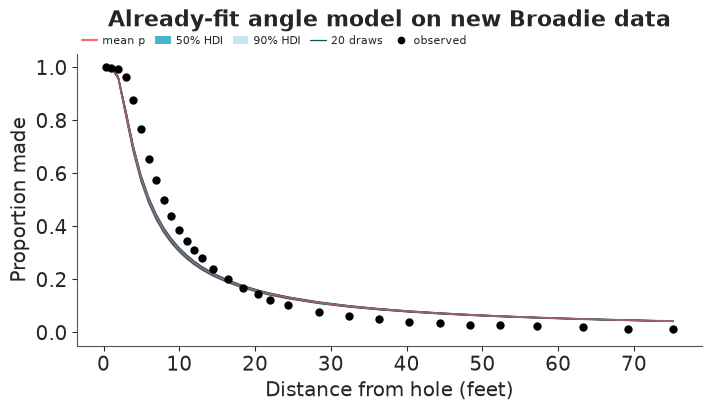

In [14]:
predictions["observed_data"]["rate"] = (
    predictions["observed_data"]["made"] / predictions["constant_data"]["attempts"]
)
new_curves = azb.extract(
    predictions,
    group="posterior_predictive",
    var_names="p_base",
    num_samples=20,
    random_seed=RANDOM_SEED,
)

azp.plot_lm(
    predictions,
    x="distance",
    y="p_base",
    y_obs="rate",
    group="posterior_predictive",
    plot_dim="obs_id",
    ci_prob=(0.50, 0.90),
    ci_kind="hdi",
    point_estimate="mean",
    smooth=False,
    figure_kwargs={"figsize": (7, 4)},
    visuals={
        "pe_line": {"color": "C1"},
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3},
    },
)

ax = plt.gca()
plot_curve_draws(ax, new_golf["distance_ft"], new_curves)
ax.set(xlabel="Distance from hole (feet)", ylabel="Proportion made", ylim=(-0.05, 1.05))
ax.set_title("Already-fit angle model on new Broadie data", pad=20)  # leave room for the legend
add_interval_legend(ax, line_label="mean p", draws_label="20 draws")
plt.show()